In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from deep_translator import GoogleTranslator
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GroupShuffleSplit


In [5]:
df = pd.read_csv("/Users/srisuphachawla/Documents/DataScience_Projects/LogisticsDataset/ActualDF.csv")

In [6]:
df

,id,year,month,product,subdistrict_origin,district_origin,province_origin,subdistrict_destination,district_destination,province_destination,trips,shipping,average_distance,average_duration,average_speed
0,1,2025,January,paddy,ตาลสุม,ตาลสุม,Ubon Ratchathani,กุดชมภู,พิบูลมังสาหาร,Ubon Ratchathani,405,9033,21.43,32.66,39.37
1,2,2025,January,paddy,พระอาจารย์,องครักษ์,Nakhon Nayok,ท่าสะอ้าน,บางปะกง,Chachoengsao,403,8981,63.93,91.61,41.87
2,3,2025,January,paddy,คำหว้า,ตาลสุม,Ubon Ratchathani,กุดชมภู,พิบูลมังสาหาร,Ubon Ratchathani,384,8567,21.89,39.93,32.89
3,4,2025,January,paddy,วังม้า,ลาดยาว,Nakhon Sawan,ท่าฉนวน,มโนรมย์,Chai Nat,331,7376,67.10,84.94,47.40
4,5,2025,January,paddy,เตย,ม่วงสามสิบ,Ubon Ratchathani,ยางโยภาพ,ม่วงสามสิบ,Ubon Ratchathani,320,7143,18.50,26.89,41.28
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
346966,346967,2025,August,car,ทุ่งสุขลา,ศรีราชา,Chonburi,สุรศักดิ์,ศรีราชา,Chonburi,1,17,18.61,52.88,21.12
346967,346968,2025,August,car,ทุ่งสุขลา,ศรีราชา,Chonburi,ไร่ส้ม,เมืองเพชรบุรี,Phetchaburi,1,17,236.98,332.48,42.77
346968,346969,2025,August,car,ทุ่งสุขลา,ศรีราชา,Chonburi,บางแก้ว,เมืองสมุทรสงคราม,Samut Songkhram,1,17,177.05,245.00,43.36
346969,346970,2025,August,car,ทุ่งสุขลา,ศรีราชา,Chonburi,คันนายาว,เขตคันนายาว,Bangkok,1,17,105.57,156.45,40.49


In [7]:
df.describe()

,id,year,trips,shipping,average_distance,average_duration,average_speed
count,346971.000000,346971.0,346971.000000,346971.000000,346971.000000,346971.000000,346971.000000
mean,173486.000000,2025.0,28.031945,776.947598,121.397510,156.876851,43.930749
std,100162.044463,0.0,163.843404,4922.222475,137.645385,175.312006,9.426172
min,1.000000,2025.0,1.000000,6.000000,3.000000,4.500000,15.000000
25%,86743.500000,2025.0,2.000000,40.000000,29.120000,44.960000,38.060000
50%,173486.000000,2025.0,5.000000,121.000000,74.950000,99.540000,45.000000
75%,260228.500000,2025.0,15.000000,369.000000,158.125000,199.210000,50.620000
max,346971.000000,2025.0,29978.000000,899332.000000,1480.180000,4444.170000,65.000000


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 346971 entries, 0 to 346970
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       346971 non-null  int64  
 1   year                     346971 non-null  int64  
 2   month                    346971 non-null  object 
 3   product                  346971 non-null  object 
 4   subdistrict_origin       346971 non-null  object 
 5   district_origin          346971 non-null  object 
 6   province_origin          346971 non-null  object 
 7   subdistrict_destination  346971 non-null  object 
 8   district_destination     346971 non-null  object 
 9   province_destination     346971 non-null  object 
 10  trips                    346971 non-null  int64  
 11  shipping                 346971 non-null  int64  
 12  average_distance         346971 non-null  float64
 13  average_duration         346971 non-null  float64
 14  aver

In [9]:
print(df.nunique())

id                         346971
year                            1
month                           5
product                        21
subdistrict_origin           4138
district_origin               877
province_origin                77
subdistrict_destination      5447
district_destination          917
province_destination           77
trips                        1644
shipping                     8753
average_distance            48140
average_duration            55370
average_speed                4995
dtype: int64


In [10]:
# convert Thai Calendar to Gregorian
df['year'] = df['year'] - 543
df["year"] = df["year"].astype(str)

### Fixing Automatic Translations

In [11]:
df["province_destination"].sort_values().unique()

array(['Amnat Charoen', 'Ang Thong', 'Ayutthaya', 'Bangkok', 'Bueng Kan',
       'Buriram', 'Chachoengsao', 'Chai Nat', 'Chaiyaphum', 'Chanthaburi',
       'Chiang Mai', 'Chiang Rai', 'Chonburi', 'Chumphon', 'Kalasin',
       'Kamphaeng Phet', 'Kanchanaburi', 'Khon Kaen', 'Krabi', 'Lampang',
       'Lamphun', 'Loei', 'Lop Buri', 'Mae Hong Son', 'Maha Sarakham',
       'Mukdahan', 'Nakhon Nayok', 'Nakhon Pathom', 'Nakhon Phanom',
       'Nakhon Ratchasima', 'Nakhon Sawan', 'Nakhon Si Thammarat', 'Nan',
       'Narathiwat', 'Nong Bua Lamphu', 'Nong Khai', 'Nonthaburi',
       'Pathum Thani', 'Pattani', 'Phang Nga', 'Phatthalung', 'Phayao',
       'Phetchabun', 'Phetchaburi', 'Phichit', 'Phitsanulok', 'Phrae',
       'Phuket', 'Prachin Buri', 'Prachuap Khiri Khan', 'Ranong',
       'Ratchaburi', 'Rayong', 'Roi Et', 'Sa Kaeo', 'Sakon Nakhon',
       'Samut Prakan', 'Samut Sakhon', 'Samut Songkhram', 'Saraburi',
       'Satun', 'Si Sa Ket', 'Sing Buri', 'Songkhla', 'Sukhothai',
       'Suph

### EDA

In [12]:
df.duplicated().sum()

np.int64(0)

#### Distribution Analysis

In [13]:
numerical_features = df.select_dtypes(include=('int64','float64')).columns
categorical_features = df.select_dtypes(include='object').columns

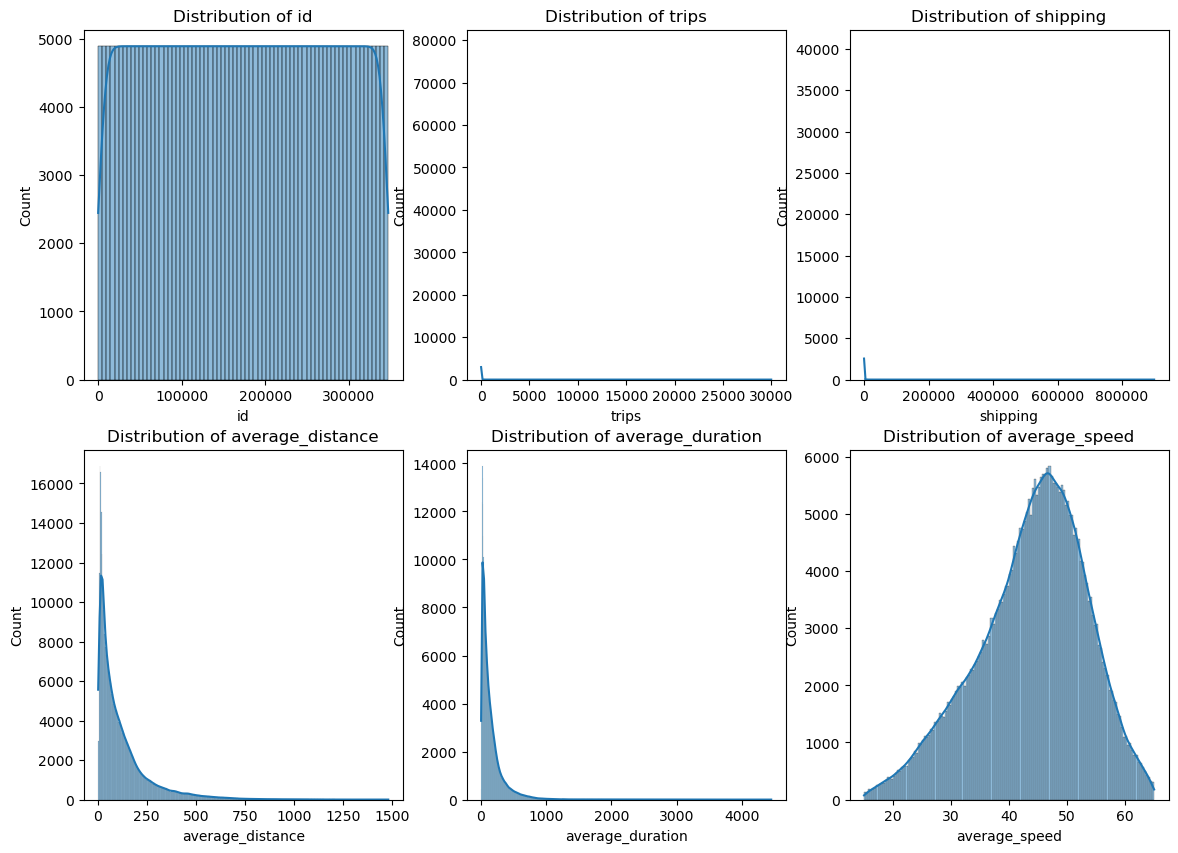

In [14]:
fig, axes = plt.subplots(2,3, figsize = (14,10))
axes = axes.flatten()

for i, j in enumerate(numerical_features):
    sns.histplot(
        df[j],
        kde=True,
        ax=axes[i]
    )
    axes[i].set_title(f"Distribution of {j}")

plt.tight_layout
plt.show()

#### Interpretation
Most variables (trips, shipping, average_distance, and average_duration) exhibit strong positive skewness, indicating that the majority of observations have low values while a few extreme observations create long right tails.

average_speed is the only variable that approximates a normal distribution, suggesting relatively stable speeds across the dataset.

The presence of outliers in the skewed variables may influence summary statistics such as the mean, making the median and interquartile range (IQR) more representative measures of central tendency and spread.

The id variable is purely an identifier and should be removed from further statistical analysis or machine learning models.


### Outlier Analysis

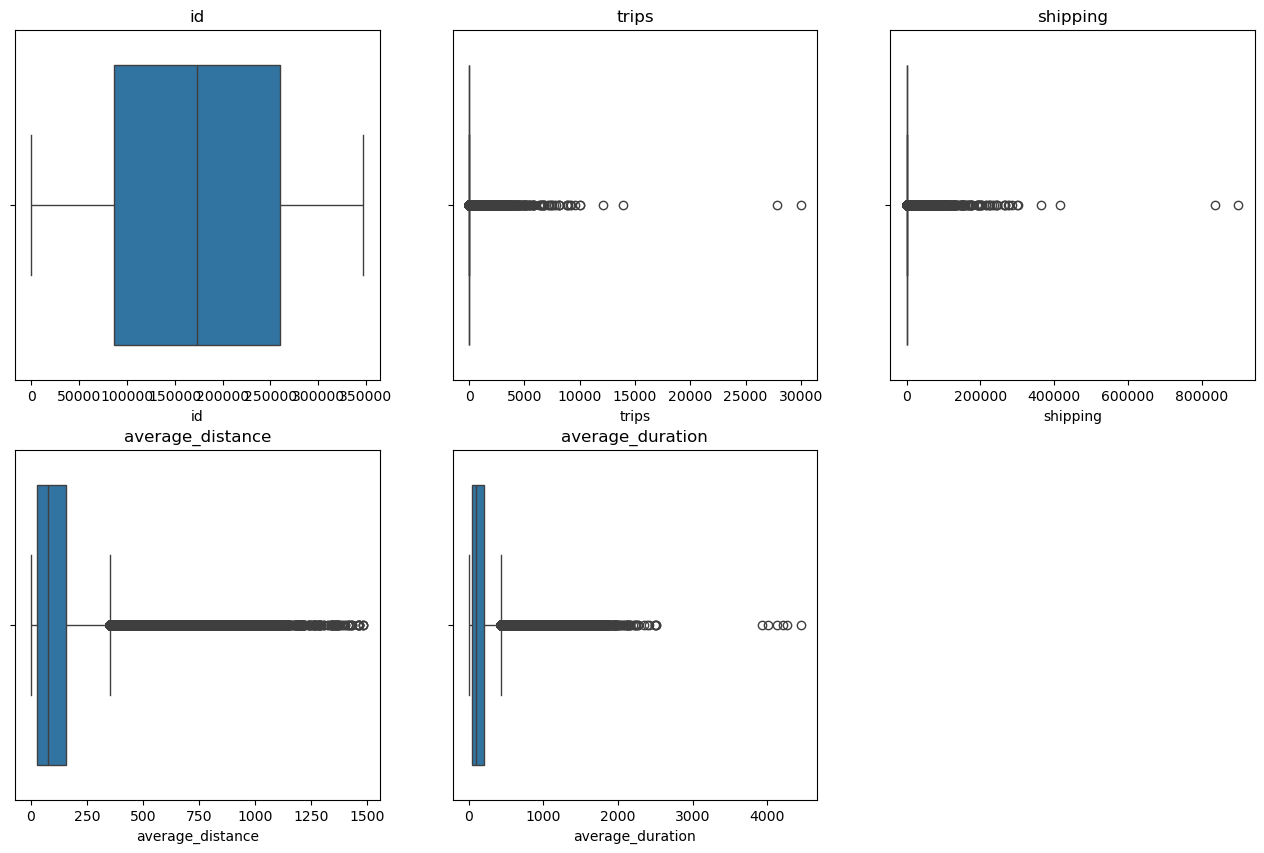

In [15]:
fig, axes = plt.subplots(2,3,figsize=(16,10))

axes=axes.flatten()


for i, col in enumerate(numerical_features):
    sns.boxplot(
        x=df[col],
        ax=axes[i]
    )
    
    axes[i].set_title(col)

fig.delaxes(axes[-1])
plt.tight_layout
plt.show()

### Interpretation:

#### Trips and Shipping

#####   Observation

Both variables are heavily right-skewed, with most routes handling relatively low volumes while a small number of routes process exceptionally large numbers of trips and shipping volumes.

##### Interpretation
Logistics operations are concentrated among a relatively small number of major transportation corridors. These high-volume routes contribute disproportionately to the overall freight network.

#### Average Distance and Average Duration
##### Observation

Most routes cover relatively short distances and travel durations, while a small number of observations represent extremely long journeys.

##### Interpretation
The majority of logistics operations occur within localized regions. Long-distance transportation represents a specialized segment of the network requiring different operational planning and resource allocation.

### Correlation Analysis

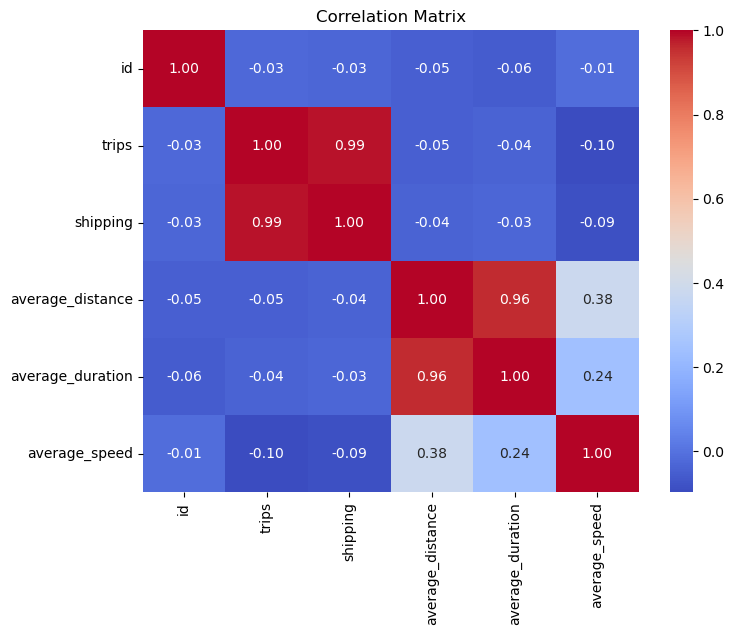

In [16]:
corr = df[numerical_features].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

#### Interpretation:

There is a high correlation between average distance and average duration, meaning that higher distance means a longer time of delivery, which is a given in general scenarios. 

#### Province Analysis

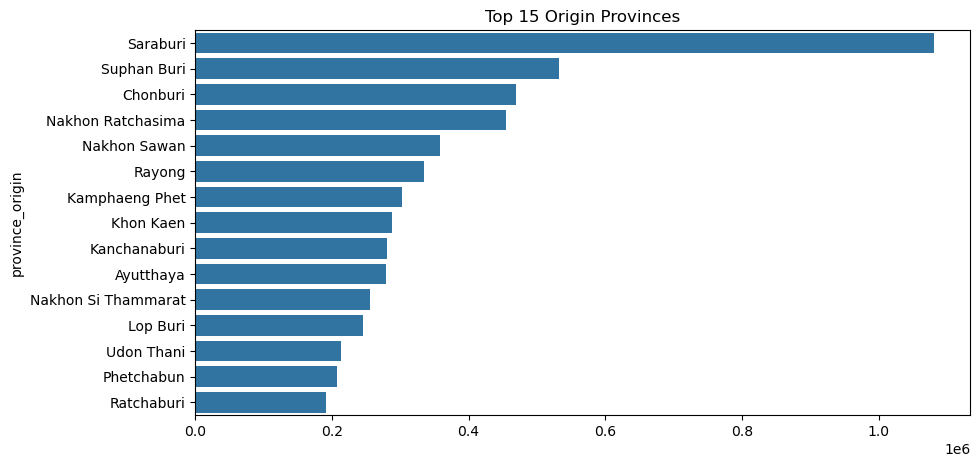

In [17]:
origin = (
    df.groupby("province_origin")["trips"]
      .sum()
      .sort_values(ascending=False)
      .head(15)
)

plt.figure(figsize=(10,5))

sns.barplot(
    x=origin.values,
    y=origin.index
)

plt.title("Top 15 Origin Provinces")

plt.show()

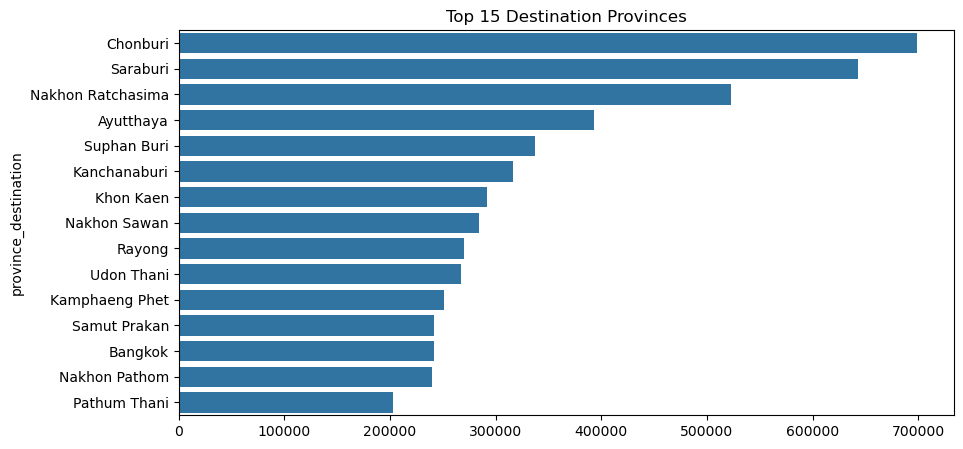

In [18]:
origin = (
    df.groupby("province_destination")["trips"]
      .sum()
      .sort_values(ascending=False)
      .head(15)
)

plt.figure(figsize=(10,5))

sns.barplot(
    x=origin.values,
    y=origin.index
)

plt.title("Top 15 Destination Provinces")

plt.show()

#### Product Analysis

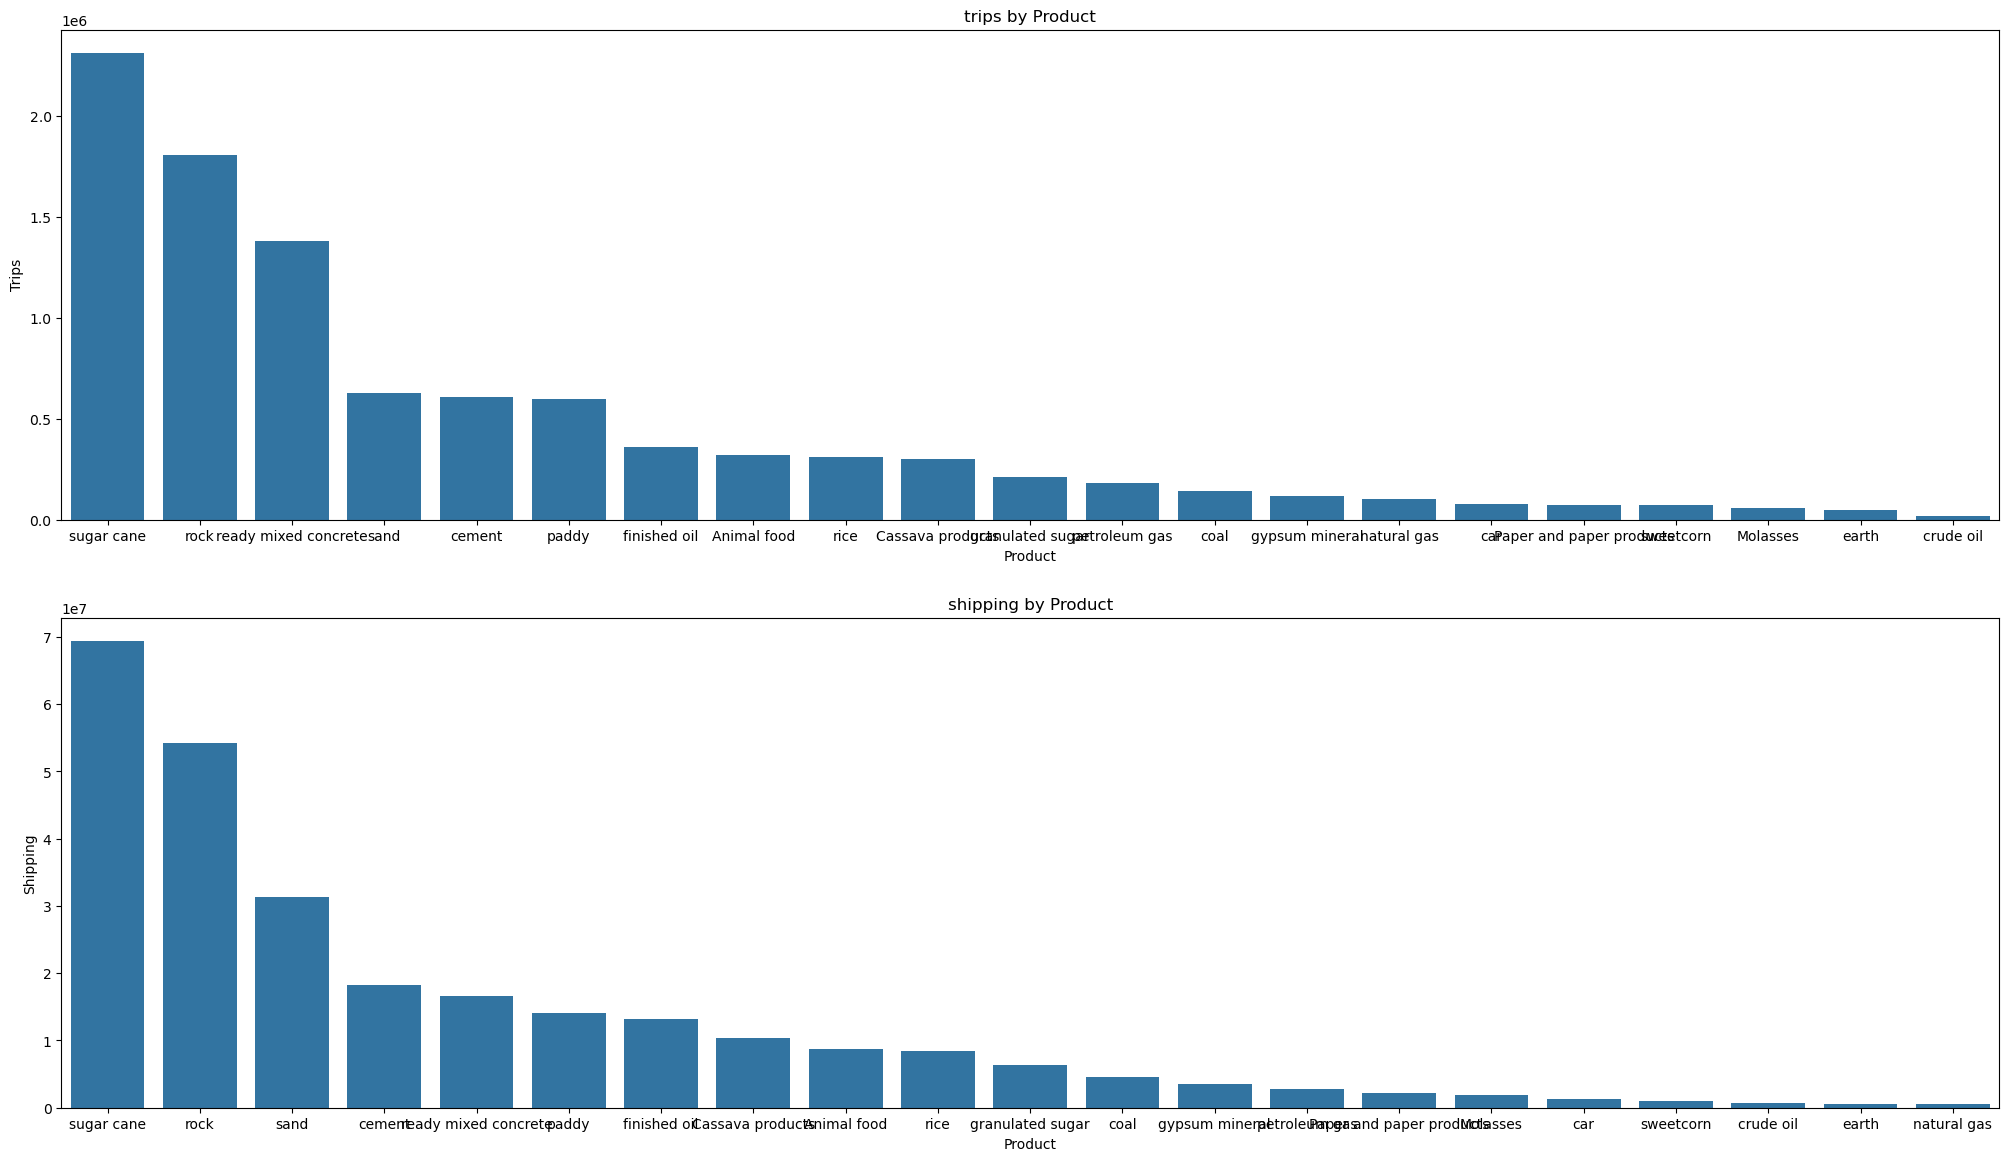

In [19]:
metrics = ['trips', 'shipping']

figs, axes = plt.subplots(2, 1, figsize=(25,14))
axes = axes.flatten()

for i, metric in enumerate(metrics):
    product_metric = (
        df.groupby('product')[metric]
        .sum()
        .sort_values(ascending=False)
          )

    sns.barplot(
        x=product_metric.index,
        y=product_metric.values,
        ax = axes[i]
    )

    axes[i].set_title(f"{metric} by Product")
    axes[i].set_xlabel("Product")
    axes[i].set_ylabel(metric.title())



plt.tight_layout
plt.show()

#### Monthly Trend - Any Seasonal Change?

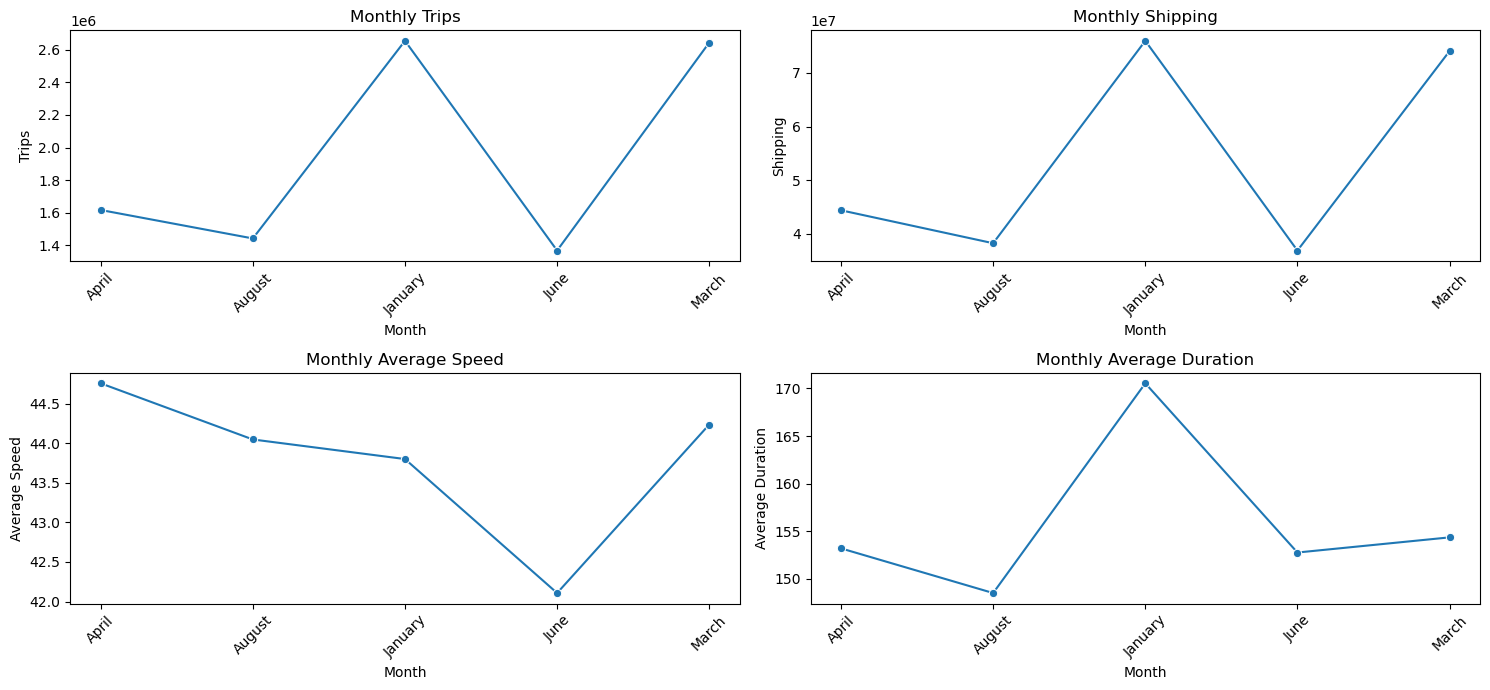

In [20]:
monthly_features = [
    "trips",
    "shipping",
    "average_speed",
    "average_duration"
]

fig, axes = plt.subplots(2, 2, figsize=(15, 7))
axes = axes.flatten()

for i, col in enumerate(monthly_features):

    monthly = (
        df.groupby("month")[col]
          .sum() if col in ["trips", "shipping"]
        else df.groupby("month")[col]
              .mean()
    )

    sns.lineplot(
        x=monthly.index,
        y=monthly.values,
        marker="o",
        ax=axes[i]
    )

    axes[i].set_title(f"Monthly {col.replace('_',' ').title()}")
    axes[i].set_xlabel("Month")
    axes[i].set_ylabel(col.replace("_"," ").title())
    axes[i].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

### Interpretation 

#### Monthly Trips and Monthly Shipping

##### Observation
Activity peaks during January and March, while the lowest levels to occur are during June and August

##### Interpretation
Operational Planning should account for predictable fluctuations in logistics Demand


#### Monthly Average Speed

##### Observation
Average vehicle speed reaches its highest value in April and declines noticeably during June.


##### Interpretation
Reduced travel speeds during mid-year may indicate increased traffic congestion, road maintenance, adverse weather conditions, or seasonal travel patterns that affect transportation efficiency. --> Monsoon Season hits in June in Thailand


#### Monthly Average Duration

##### Observation

Average travel duration reaches its highest level during January, while remaining relatively stable throughout the rest of the year.

##### Interpretation

Although January records the highest freight volume, shipments also require more time to complete. This may indicate operational bottlenecks caused by increased demand or seasonal factors affecting transport efficiency.





### Route Analysis 

In [21]:
df['Route'] = (
    df['province_origin'] + " -> " + df['province_destination']
)

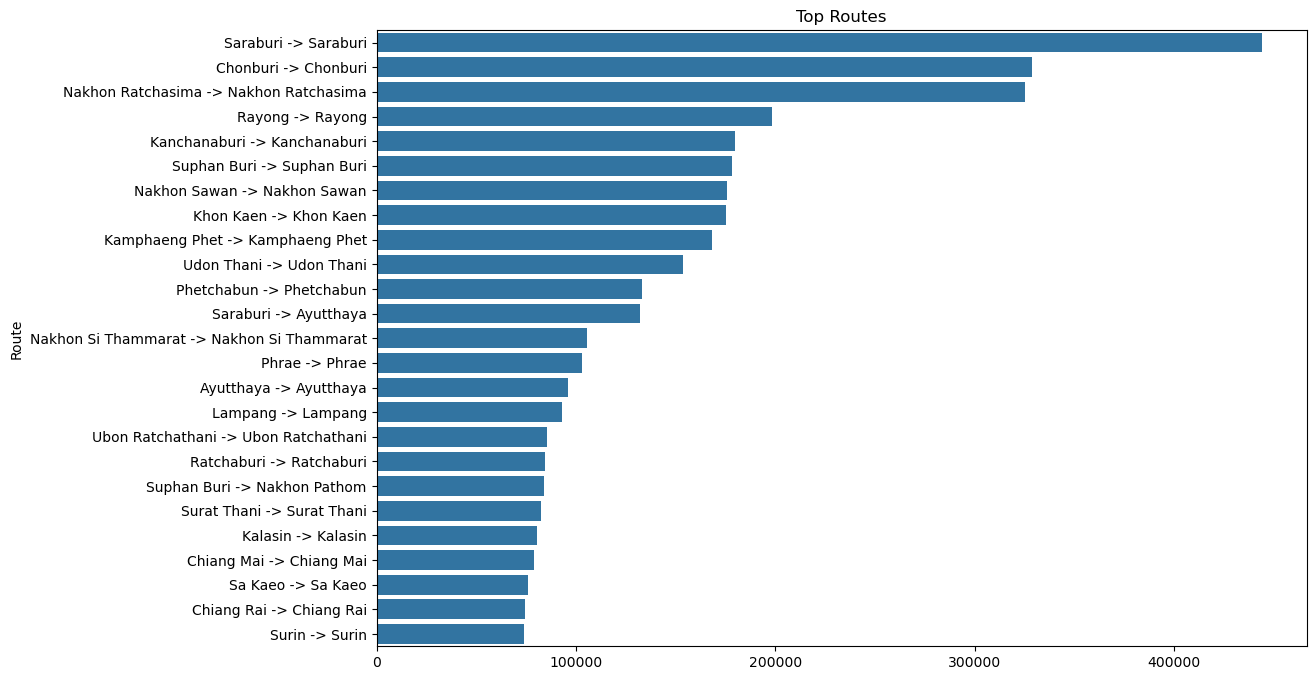

In [22]:
routes = (
    df.groupby("Route")['trips']
    .sum()
    .sort_values(ascending=False)
    .head(25)
)

plt.figure(figsize=(12,8))

sns.barplot(
    x=routes.values,
    y=routes.index
)

plt.title("Top Routes")
plt.show()

#### Interpretation:

Most Routes cover deliveries from one location to another in the same province, rather than transporting from one province or another. 

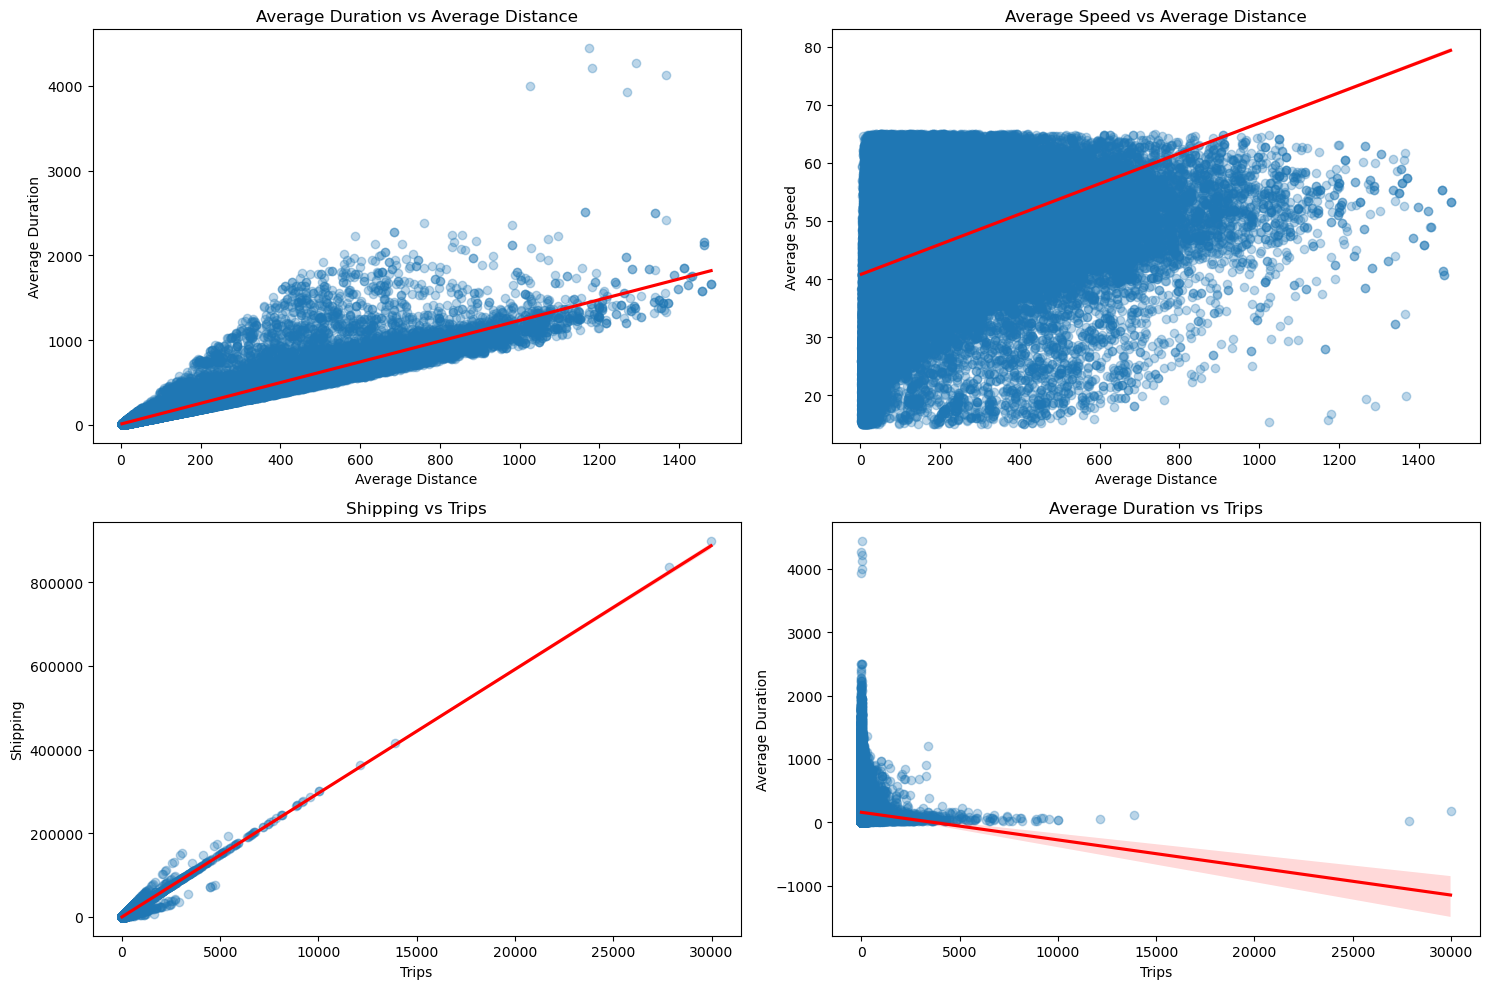

In [23]:
scatter_pairs = [
    ("average_distance", "average_duration"),
    ("average_distance", "average_speed"),
    ("trips", "shipping"),
    ("trips", "average_duration")
]

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for i, (x, y) in enumerate(scatter_pairs):

    sns.regplot(
    data=df,
    x=x,
    y=y,
    scatter_kws={"alpha": 0.3},
    line_kws={"color": "red"},
    ax=axes[i]
)

    axes[i].set_title(f"{y.replace('_',' ').title()} vs {x.replace('_',' ').title()}")
    axes[i].set_xlabel(x.replace("_"," ").title())
    axes[i].set_ylabel(y.replace("_"," ").title())

plt.tight_layout()
plt.show()

### Interpretation

#### Average Duration vs. Average Distance
##### Observation

There is a strong positive linear relationship between average distance and average duration. As the travel distance increases, the travel duration also increases in a predictable manner. However, the spread of the data becomes larger for routes exceeding approximately 600 distance units.

##### Interpretation
This indicates that travel time is primarily driven by travel distance. The larger variation observed on long-distance routes suggests that additional factors such as road conditions, traffic congestion, rest stops, and weather have a greater impact on longer journeys than on shorter ones.

#### Average Speed vs. Average Distance
##### Observation
Average speed increases with route distance until stabilizing around 65 units. Short-distance routes exhibit much greater variation in speed, while long-distance routes consistently operate near the upper speed limit.

##### Interpretation
Short-distance routes are more likely to travel through urban areas where congestion, intersections, and traffic signals reduce speed consistency. In contrast, longer routes primarily use highways, allowing vehicles to maintain higher and more stable travel speeds.

#### Shipping vs. Number of Trips
##### Observation

Shipping volume increases almost perfectly linearly with the number of trips.

##### Interpretation

Routes with more trips consistently transport larger shipping volumes. This suggests that freight demand scales proportionally with route activity and that shipment sizes remain relatively consistent across routes.

#### Average Duration vs. Number of Trips
##### Observation

Routes with the highest trip frequencies generally have shorter travel durations, whereas routes with extremely long travel durations tend to have relatively few trips.

##### Interpretation
Frequently travelled routes are primarily short-distance local or regional deliveries. Long-distance routes are less frequently travelled and typically represent specialized or inter-regional transportation.

### ML Modeling:
- Predicting Shipping Duration 

In [24]:
target = "average_duration"

features = [
    "month",
    "product",
    "province_origin",
    "province_destination",
    "average_distance",
    "average_speed",
    "trips",
    "shipping"
]

In [25]:
X = df[features]
y = df[target]

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


In [27]:
X_encoded = pd.get_dummies(
    X,
    columns=[
        "month",
        "product",
        "province_origin",
        "province_destination"
    ],
    drop_first=True
)

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.20,
    random_state=42
)

In [28]:
model_lr = LinearRegression()

model_lr.fit(X_train, y_train)

LinearRegression()

In [29]:
y_pred_lr = model_lr.predict(X_test)

In [30]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred_lr)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2 = r2_score(y_test, y_pred_lr)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 17.673878970434885
RMSE: 39.182434339296385
R²: 0.9495189535554801


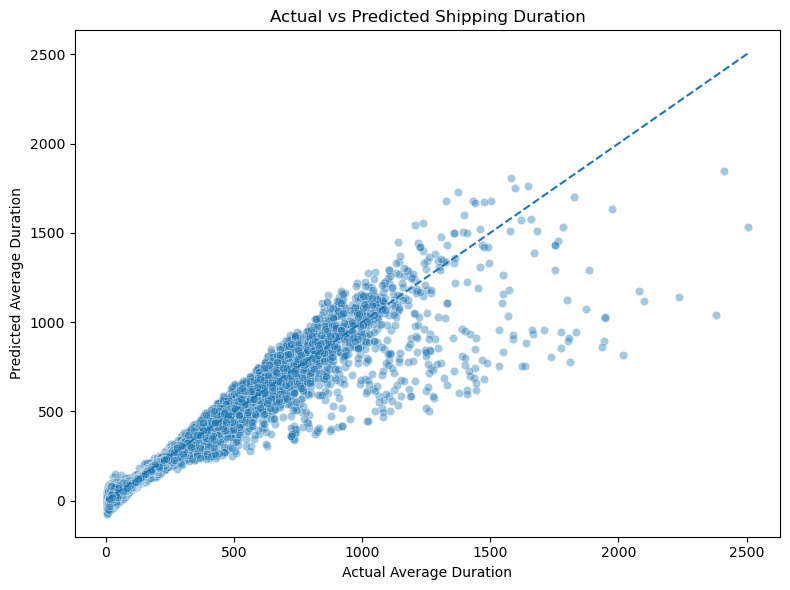

In [31]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=y_test,
    y=y_pred_lr,
    alpha=0.4
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual Average Duration")
plt.ylabel("Predicted Average Duration")
plt.title("Actual vs Predicted Shipping Duration")

plt.tight_layout()
plt.show()

In [32]:
# 10 worst predictions

error_df = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred_lr
})

error_df["Error"] = error_df["Actual"] - error_df["Predicted"]
error_df["Absolute_Error"] = error_df["Error"].abs()

error_df.sort_values(
    "Absolute_Error",
    ascending=False
).head(10)

,Actual,Predicted,Error,Absolute_Error
55126,2382.33,1038.319035,1344.010965,1344.010965
31295,2017.48,817.316099,1200.163901,1200.163901
212557,2238.06,1139.849775,1098.210225,1098.210225
28403,1937.10,859.397411,1077.702589,1077.702589
28303,1945.62,895.140789,1050.479211,1050.479211
17180,1812.33,776.803102,1035.526898,1035.526898
56526,2099.39,1116.604394,982.785606,982.785606
17071,2505.37,1531.337207,974.032793,974.032793
28638,1738.73,805.573068,933.156932,933.156932
4480,1946.28,1024.961171,921.318829,921.318829


#### The model is underpredicting the extreme duration routes

In [33]:

from sklearn.metrics import mean_absolute_percentage_error

mape = mean_absolute_percentage_error(
    y_test,
    y_pred_lr
)

print("MAPE:", mape)
print("MAPE (%):", mape * 100)

MAPE: 0.27905960465937846
MAPE (%): 27.905960465937845


In [34]:
error_analysis = X_test.copy()

error_analysis["Actual_Duration"] = y_test
error_analysis["Predicted_Duration"] = y_pred_lr

error_analysis["Absolute_Error"] = (
    error_analysis["Actual_Duration"]
    - error_analysis["Predicted_Duration"]
).abs()

error_analysis.sort_values(
    "Absolute_Error",
    ascending=False
).head(10)

,average_distance,average_speed,trips,shipping,month_August,month_January,month_June,month_March,product_Cassava products,product_Molasses,...,province_destination_Trat,province_destination_Ubon Ratchathani,province_destination_Udon Thani,province_destination_Uthai Thani,province_destination_Uttaradit,province_destination_Yala,province_destination_Yasothon,Actual_Duration,Predicted_Duration,Absolute_Error
55126,760.46,19.15,2,63,False,True,False,False,False,False,...,False,False,False,False,False,False,False,2382.33,1038.319035,1344.010965
31295,559.29,16.63,4,58,False,True,False,False,False,False,...,False,False,False,False,False,False,False,2017.48,817.316099,1200.163901
212557,854.34,22.90,3,96,False,False,False,False,False,False,...,False,False,False,False,False,False,False,2238.06,1139.849775,1098.210225
28403,601.54,18.63,6,152,False,True,False,False,False,False,...,False,True,False,False,False,False,False,1937.10,859.397411,1077.702589
28303,629.67,19.42,7,182,False,True,False,False,False,False,...,False,True,False,False,False,False,False,1945.62,895.140789,1050.479211
17180,529.55,17.53,1,30,False,True,False,False,False,False,...,False,False,False,False,False,False,False,1812.33,776.803102,1035.526898
56526,829.34,23.70,2,63,False,True,False,False,False,False,...,False,False,False,False,False,False,False,2099.39,1116.604394,982.785606
17071,1164.39,27.89,1,30,False,True,False,False,False,False,...,False,False,False,False,False,False,False,2505.37,1531.337207,974.032793
28638,573.69,19.80,6,152,False,True,False,False,False,False,...,False,False,False,False,False,False,False,1738.73,805.573068,933.156932
4480,745.80,22.99,26,701,False,True,False,False,False,False,...,False,False,False,False,False,False,False,1946.28,1024.961171,921.318829


In [ ]:
features = [
    "month",
    "product",
    "province_origin",
    "province_destination",
    "average_distance"
]

X = df[features]
y = df[target]


df["route"] = (
    df["province_origin"].astype(str)
    + " → "
    + df["province_destination"].astype(str)
)

groups = df["route"]


gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    gss.split(X, y, groups=groups)
)

In [36]:
X_train = X.iloc[train_idx].copy()
X_test = X.iloc[test_idx].copy()

y_train = y.iloc[train_idx].copy()
y_test = y.iloc[test_idx].copy()

In [37]:
train_routes = set(
    groups.iloc[train_idx]
)

test_routes = set(
    groups.iloc[test_idx]
)

overlap = train_routes.intersection(test_routes)

print("Training routes:", len(train_routes))
print("Testing routes:", len(test_routes))
print("Overlapping routes:", len(overlap))

Training routes: 2499
Testing routes: 625
Overlapping routes: 0


In [38]:
categorical_cols = [
    "month",
    "product",
    "province_origin",
    "province_destination"
]

X_train_encoded = pd.get_dummies(
    X_train,
    columns=categorical_cols,
    drop_first=True
)

X_test_encoded = pd.get_dummies(
    X_test,
    columns=categorical_cols,
    drop_first=True
)

X_train_encoded, X_test_encoded = X_train_encoded.align(
    X_test_encoded,
    join="left",
    axis=1,
    fill_value=0
)

In [47]:
rf_model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train_encoded,
    y_train
)

y_pred_rf = rf_model.predict(
    X_test_encoded
)

mae_rf = mean_absolute_error(
    y_test,
    y_pred_rf
)

rmse_rf = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_rf
    )
)

r2_rf = r2_score(
    y_test,
    y_pred_rf
)

print("Random Forest on Unseen Routes")
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("R²:", r2_rf)

Random Forest on Unseen Routes
MAE: 18.137860239717604
RMSE: 46.75923447195739
R²: 0.9229007290062919


In [41]:
rf_errors = pd.DataFrame({
    "Actual_Duration": y_test.values,
    "Predicted_Duration": y_pred_rf
})

rf_errors["Error"] = (
    rf_errors["Actual_Duration"]
    - rf_errors["Predicted_Duration"]
)

rf_errors["Absolute_Error"] = (
    rf_errors["Error"].abs()
)

rf_errors.sort_values(
    "Absolute_Error",
    ascending=False
).head(10)

,Actual_Duration,Predicted_Duration,Error,Absolute_Error
49630,1381.23,3115.199833,-1733.969833,1733.969833
2141,2271.49,847.480800,1424.009200,1424.009200
3529,2271.49,848.369200,1423.120800,1423.120800
5962,2136.31,920.836167,1215.473833,1215.473833
6141,1987.31,793.608100,1193.701900,1193.701900
11249,1820.42,712.028700,1108.391300,1108.391300
1108,1833.12,759.206233,1073.913767,1073.913767
2496,1833.12,761.075333,1072.044667,1072.044667
3528,1774.42,751.631633,1022.788367,1022.788367
2140,1774.42,752.220100,1022.199900,1022.199900


In [ ]:
lr_grouped = LinearRegression()

lr_grouped.fit(
    X_train_encoded,
    y_train
)

y_pred_lr_grouped = lr_grouped.predict(
    X_test_encoded
)

In [43]:
mae_lr_grouped = mean_absolute_error(
    y_test,
    y_pred_lr_grouped
)

rmse_lr_grouped = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_lr_grouped
    )
)

r2_lr_grouped = r2_score(
    y_test,
    y_pred_lr_grouped
)

print("Linear Regression on Unseen Routes")
print("MAE:", mae_lr_grouped)
print("RMSE:", rmse_lr_grouped)
print("R²:", r2_lr_grouped)

Linear Regression — Unseen Routes
----------------------------------
MAE: 20.407339059446937
RMSE: 45.10851350173456
R²: 0.9282482466426965


In [46]:
comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest"
    ],
    "MAE": [
        mae_lr_grouped,
        mae_rf
    ],
    "RMSE": [
        rmse_lr_grouped,
        rmse_rf
    ],
    "R²": [
        r2_lr_grouped,
        r2_rf
    ]
})

comparison

,Model,MAE,RMSE,R²
0,Linear Regression,20.407339,45.108514,0.928248
1,Random Forest,18.137860,46.759234,0.922901


In [53]:
rf_results = df.iloc[test_idx][[
    "id",
    "month",
    "product",
    "province_origin",
    "province_destination",
    "average_distance",
    "average_duration"
]].copy()

rf_results["Predicted_Duration"] = y_pred_rf

rf_results["Absolute_Error"] = (
    rf_results["average_duration"]
    - rf_results["Predicted_Duration"]
).abs()

rf_results = rf_results.sort_values(
    "Absolute_Error",
    ascending=False
)

rf_results.head(20)

,id,month,product,province_origin,province_destination,average_distance,average_duration,Predicted_Duration,Absolute_Error
243808,243809,June,rice,Chaiyaphum,Songkhla,1278.37,1381.23,3115.199833,1733.969833
10628,10629,January,paddy,Yasothon,Samut Sakhon,685.29,2271.49,847.480800,1424.009200
17670,17671,January,rice,Yasothon,Samut Sakhon,685.29,2271.49,848.369200,1423.120800
29739,29740,January,Animal food,Lop Buri,Chiang Rai,706.21,2136.31,920.836167,1215.473833
30568,30569,January,Animal food,Suphan Buri,Chiang Mai,646.78,1987.31,793.608100,1193.701900
56307,56308,January,cement,Saraburi,Lampang,521.17,1820.42,712.028700,1108.391300
5506,5507,January,paddy,Uttaradit,Nakhon Pathom,679.60,1833.12,759.206233,1073.913767
12548,12549,January,rice,Uttaradit,Nakhon Pathom,679.60,1833.12,761.075333,1072.044667
17668,17669,January,rice,Mukdahan,Chachoengsao,586.29,1774.42,751.631633,1022.788367
10626,10627,January,paddy,Mukdahan,Chachoengsao,586.29,1774.42,752.220100,1022.199900


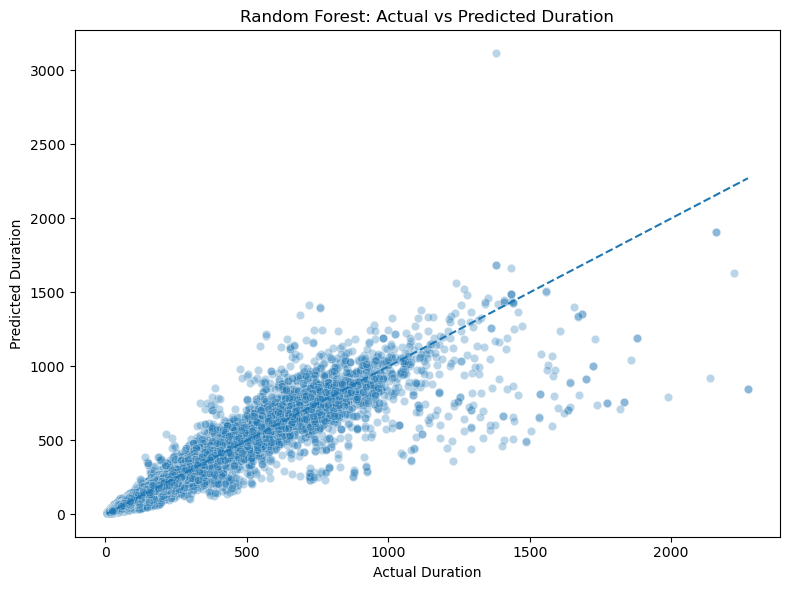

In [50]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=y_test,
    y=y_pred_rf,
    alpha=0.3
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual Duration")
plt.ylabel("Predicted Duration")
plt.title("Random Forest: Actual vs Predicted Duration")

plt.tight_layout()
plt.show()

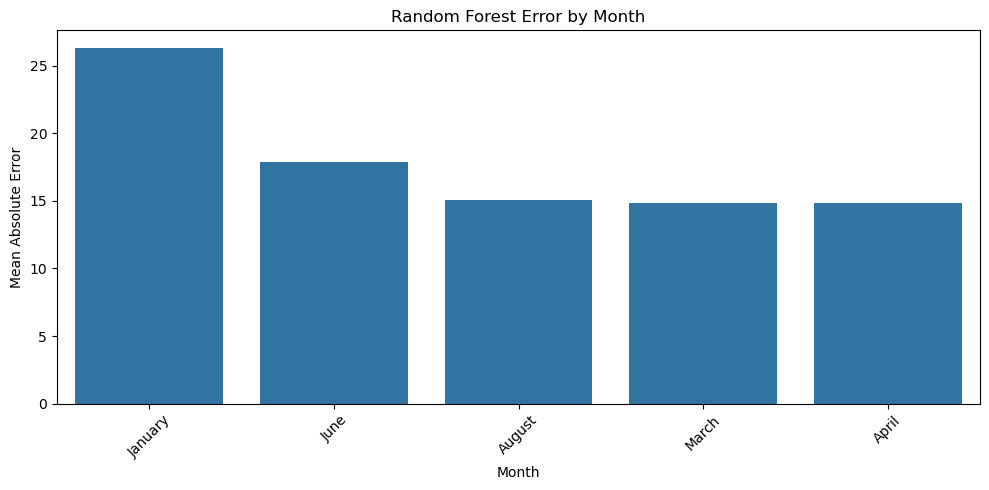

In [54]:
rf_results.head(20)[[
    "month",
    "product",
    "province_origin",
    "province_destination",
    "average_distance",
    "average_duration",
    "Predicted_Duration",
    "Absolute_Error"
]]

monthly_error = (
    rf_results
    .groupby("month")["Absolute_Error"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 5))

sns.barplot(
    x=monthly_error.index,
    y=monthly_error.values
)

plt.ylabel("Mean Absolute Error")
plt.xlabel("Month")
plt.title("Random Forest Error by Month")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

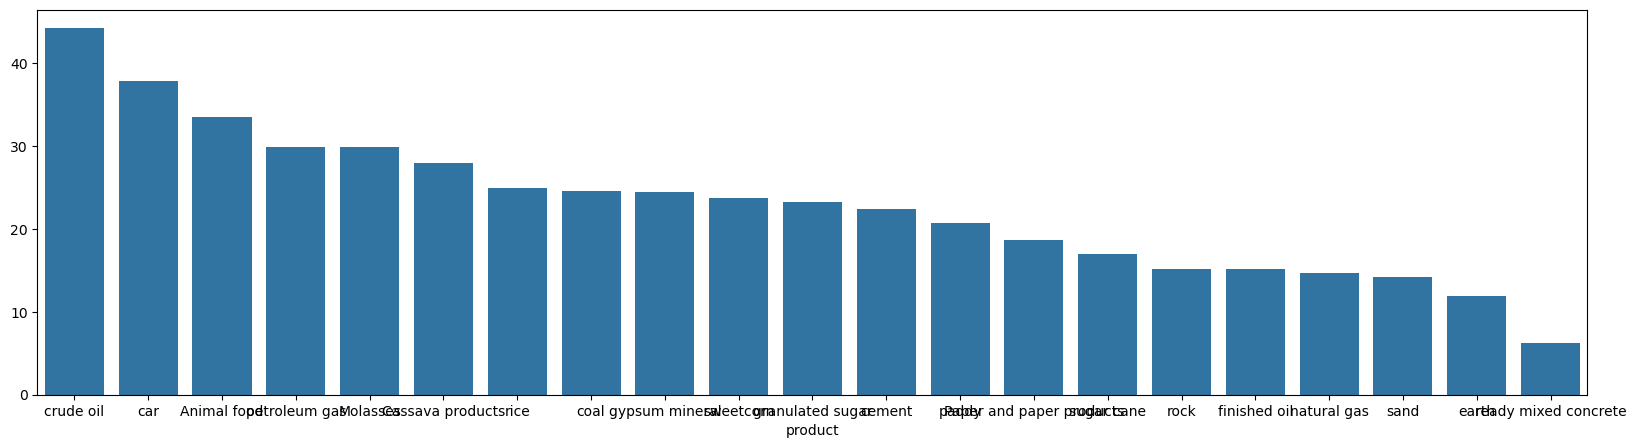

In [57]:
product_error = (
    rf_results
    .groupby("product")['Absolute_Error']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(20, 5))

sns.barplot(
    x=product_error.index,
    y=product_error.values
)

plt.tight_layout
plt.show()

#### Since January for month and Crude Oil and Car for Products, we compare their duration distribution 

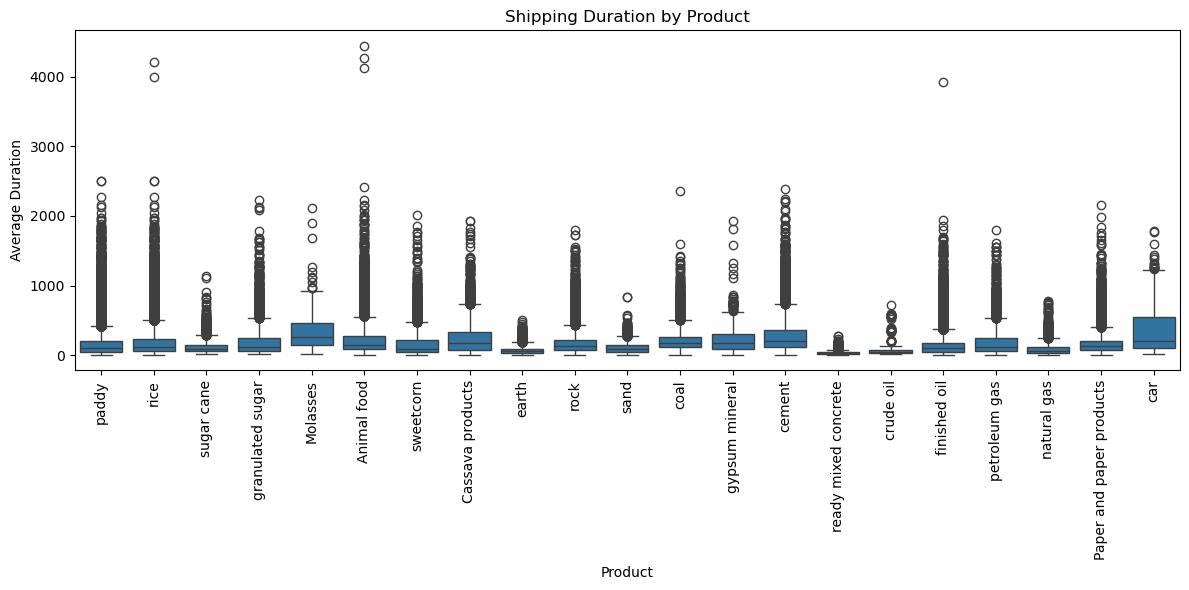

In [58]:
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df,
    x="product",
    y="average_duration"
)

plt.xticks(rotation=90)
plt.title("Shipping Duration by Product")
plt.xlabel("Product")
plt.ylabel("Average Duration")

plt.tight_layout()
plt.show()

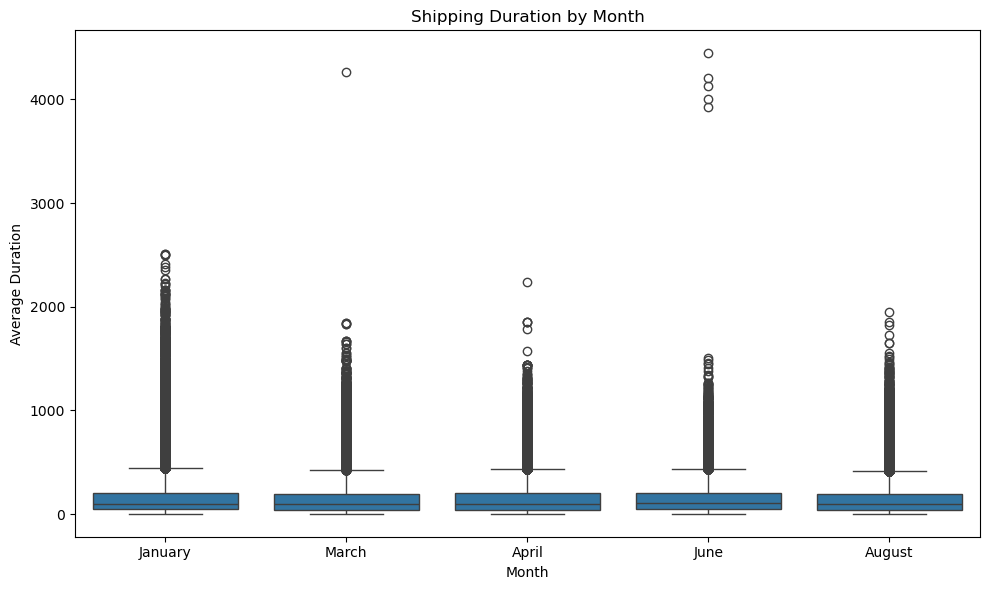

In [59]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="month",
    y="average_duration"
)

plt.title("Shipping Duration by Month")
plt.xlabel("Month")
plt.ylabel("Average Duration")

plt.tight_layout()
plt.show()

In [60]:
product_month_error = (
    rf_results
    .groupby(["product", "month"])["Absolute_Error"]
    .mean()
    .reset_index()
    .sort_values("Absolute_Error", ascending=False)
)

product_month_error.head(20)

,product,month,Absolute_Error
37,crude oil,January,84.071771
2,Animal food,January,53.605857
22,car,January,51.808634
100,sweetcorn,January,51.621522
57,gypsum mineral,January,49.681935
12,Molasses,January,49.027909
82,rice,January,45.563787
72,petroleum gas,January,44.894157
67,paddy,January,37.506651
7,Cassava products,January,36.560923


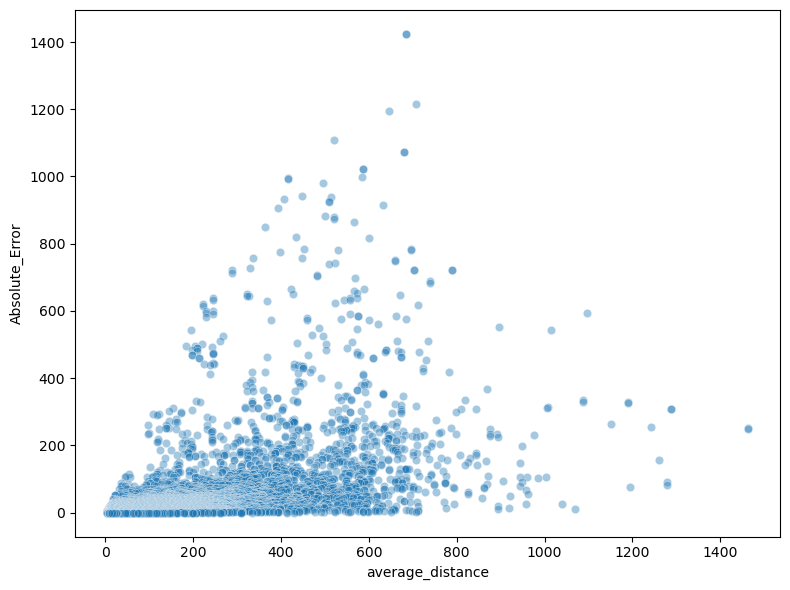

In [ ]:
january_errors = rf_results[rf_results['month'] == 'January'].copy()

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=january_errors,
    x='average_distance',
    y='Absolute_Error',
    alpha = 0.4
)

plt.tight_layout()
plt.show()


In [65]:
january_errors = rf_results[
    rf_results["month"] == "January"
].copy()

january_errors[[
    "average_distance",
    "average_duration",
    "Predicted_Duration",
    "Absolute_Error"
]].sort_values(
    "Absolute_Error",
    ascending=False
).head(20)

,average_distance,average_duration,Predicted_Duration,Absolute_Error
10628,685.29,2271.49,847.480800,1424.009200
17670,685.29,2271.49,848.369200,1423.120800
29739,706.21,2136.31,920.836167,1215.473833
30568,646.78,1987.31,793.608100,1193.701900
56307,521.17,1820.42,712.028700,1108.391300
5506,679.60,1833.12,759.206233,1073.913767
12548,679.60,1833.12,761.075333,1072.044667
17668,586.29,1774.42,751.631633,1022.788367
10626,586.29,1774.42,752.220100,1022.199900
34923,583.63,1738.47,740.303000,998.167000


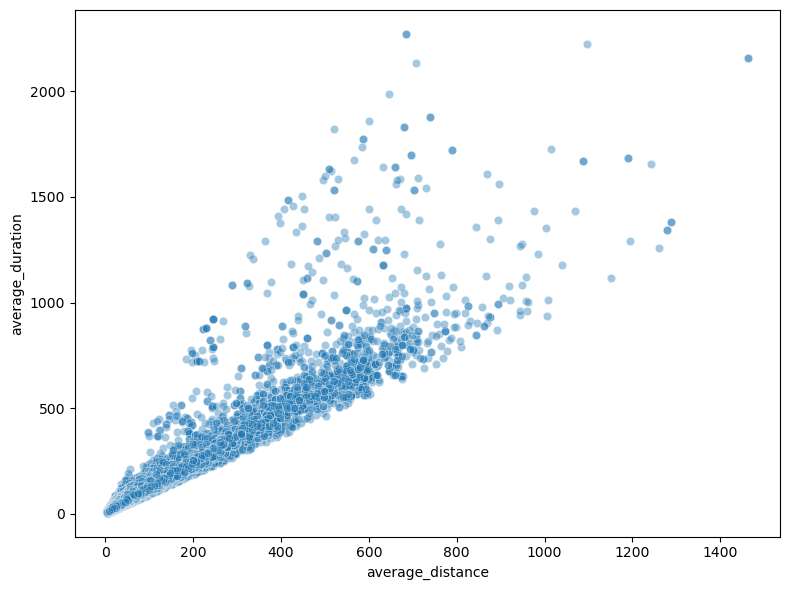

In [64]:
january_errors = rf_results[rf_results['month'] == 'January'].copy()

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=january_errors,
    x='average_distance',
    y='average_duration',
    alpha = 0.4
)

plt.tight_layout()
plt.show()

In [67]:
month_error_summary = (
    rf_results
    .groupby("month")
    .agg(
        Mean_Error=("Absolute_Error", "mean"),
        Median_Error=("Absolute_Error", "median"),
        Max_Error=("Absolute_Error", "max"),
        Observations=("Absolute_Error", "count")
    )
    .sort_values("Mean_Error", ascending=False)
)

print(month_error_summary)

         Mean_Error  Median_Error    Max_Error  Observations
month                                                       
January   26.322726      8.137067  1424.009200         17717
June      17.863429     10.144200  1733.969833          9183
August    15.102225      7.924967   811.698878         13337
March     14.883993      7.584100   938.003100         16777
April     14.833466      7.797733   868.420867         14349


mean error of 26.32 but the median is not so different from others, Janueayr high MAE -> outliers -> model bad on every January Shipment

In [69]:
duration_by_month = (
    df
    .groupby("month")["average_duration"]
    .agg([
        "count",
        "mean",
        "median",
        "std",
        "min",
        "max"
    ])
    .sort_values("mean", ascending=False)
)

print(duration_by_month)

         count        mean   median         std   min      max
month                                                         
January  86282  170.541282  100.975  209.360085  4.99  2505.37
March    81993  154.364763   97.550  167.735337  4.50  4265.83
April    71141  153.208435   99.360  160.171516  4.89  2238.06
June     43923  152.773693  104.610  159.568414  5.03  4444.17
August   63632  148.519058   96.820  159.016026  6.00  1947.82


In [70]:
january_worst = (
    rf_results[
        rf_results["month"] == "January"
    ]
    .sort_values(
        "Absolute_Error",
        ascending=False
    )
)

january_worst[[
    "product",
    "province_origin",
    "province_destination",
    "average_distance",
    "average_duration",
    "Predicted_Duration",
    "Absolute_Error"
]].head(20)

,product,province_origin,province_destination,average_distance,average_duration,Predicted_Duration,Absolute_Error
10628,paddy,Yasothon,Samut Sakhon,685.29,2271.49,847.480800,1424.009200
17670,rice,Yasothon,Samut Sakhon,685.29,2271.49,848.369200,1423.120800
29739,Animal food,Lop Buri,Chiang Rai,706.21,2136.31,920.836167,1215.473833
30568,Animal food,Suphan Buri,Chiang Mai,646.78,1987.31,793.608100,1193.701900
56307,cement,Saraburi,Lampang,521.17,1820.42,712.028700,1108.391300
5506,paddy,Uttaradit,Nakhon Pathom,679.60,1833.12,759.206233,1073.913767
12548,rice,Uttaradit,Nakhon Pathom,679.60,1833.12,761.075333,1072.044667
17668,rice,Mukdahan,Chachoengsao,586.29,1774.42,751.631633,1022.788367
10626,paddy,Mukdahan,Chachoengsao,586.29,1774.42,752.220100,1022.199900
34923,Cassava products,Kalasin,Ratchaburi,583.63,1738.47,740.303000,998.167000
